In [ ]:
pip install datasets

In [ ]:
pip install evaluate

In [7]:
import pandas as pd
import numpy as np


In [8]:
df = pd.read_csv("1429_1.csv")  # Or whatever filename is present


<ipython-input-8-fabeb2a52329>:1: DtypeWarning: Columns (1,10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("1429_1.csv")  # Or whatever filename is present


In [9]:
df.head()

,id,name,asins,brand,categories,keys,manufacturer,reviews.date,reviews.dateAdded,reviews.dateSeen,...,reviews.doRecommend,reviews.id,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.userCity,reviews.userProvince,reviews.username
0,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,This product so far has not disappointed. My c...,Kindle,NaN,NaN,Adapter
1,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,great for beginner or experienced person. Boug...,very fast,NaN,NaN,truman
2,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,Inexpensive tablet for him to use and learn on...,Beginner tablet for our 9 year old son.,NaN,NaN,DaveZ
3,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,4.0,http://reviews.bestbuy.com/3545/5620406/review...,I've had my Fire HD 8 two weeks now and I love...,Good!!!,NaN,NaN,Shacks
4,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-12T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,I bought this for my grand daughter when she c...,Fantastic Tablet for kids,NaN,NaN,explore42


In [10]:
df.columns

Index(['id', 'name', 'asins', 'brand', 'categories', 'keys', 'manufacturer',
       'reviews.date', 'reviews.dateAdded', 'reviews.dateSeen',
       'reviews.didPurchase', 'reviews.doRecommend', 'reviews.id',
       'reviews.numHelpful', 'reviews.rating', 'reviews.sourceURLs',
       'reviews.text', 'reviews.title', 'reviews.userCity',
       'reviews.userProvince', 'reviews.username'],
      dtype='object')

In [11]:
df = df.loc[:, ['reviews.rating','reviews.text','reviews.title']]


In [12]:
df.isnull().sum()

,0
reviews.rating,33
reviews.text,1
reviews.title,6


In [13]:
df['reviews.rating'].value_counts()

,count
reviews.rating,
5.0,23775
4.0,8541
3.0,1499
1.0,410
2.0,402


In [14]:
df.dropna(inplace=True)

In [15]:
df.isnull()

,reviews.rating,reviews.text,reviews.title
0,False,False,False
1,False,False,False
2,False,False,False
3,False,False,False
4,False,False,False
...,...,...,...
34655,False,False,False
34656,False,False,False
34657,False,False,False
34658,False,False,False


In [16]:
df.describe()

,reviews.rating
count,34620.000000
mean,4.584518
std,0.735700
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


In [17]:
df.shape

(34620, 3)

In [18]:
df.columns.duplicated()

array([False, False, False])

In [19]:
def map_rating_to_sentiment(rating):
    if rating in [1, 2]:
        return 2
    elif rating == 3:
        return 0
    else:
        return 1

df["sentiment"] = df["reviews.rating"].apply(map_rating_to_sentiment)


In [20]:
df['reviews.rating'].unique()

array([5., 4., 2., 1., 3.])

In [21]:
df.head()

,reviews.rating,reviews.text,reviews.title,sentiment
0,5.0,This product so far has not disappointed. My c...,Kindle,1
1,5.0,great for beginner or experienced person. Boug...,very fast,1
2,5.0,Inexpensive tablet for him to use and learn on...,Beginner tablet for our 9 year old son.,1
3,4.0,I've had my Fire HD 8 two weeks now and I love...,Good!!!,1
4,5.0,I bought this for my grand daughter when she c...,Fantastic Tablet for kids,1


In [22]:
df.sentiment.value_counts()

,count
sentiment,
1,32309
0,1499
2,812


In [23]:
clean_df = df.copy()

In [24]:
clean_df.sentiment.value_counts() # checking label distribution

,count
sentiment,
1,32309
0,1499
2,812


In [25]:
from random import sample
# create balanced datase
negative_reviews = clean_df[clean_df['sentiment'] == 0].sample(n=5000, replace=True)
neutral_reviews = clean_df[clean_df['sentiment'] == 1].sample(n=5000, replace=True)
positive_reviews = clean_df[clean_df['sentiment'] == 2].sample(n=5000, replace=True)

sampled_df = pd.concat([negative_reviews, neutral_reviews, positive_reviews])

In [26]:
sampled_df.sentiment.value_counts() # checking label distribution

,count
sentiment,
0,5000
1,5000
2,5000


In [27]:
sampled_df.isnull().sum()

,0
reviews.rating,0
reviews.text,0
reviews.title,0
sentiment,0


In [28]:
sampled_df["review_body"] = sampled_df["reviews.title"].astype(str) + ". " + sampled_df["reviews.text"].astype(str)


In [29]:
sampled_df

,reviews.rating,reviews.text,reviews.title,sentiment,review_body
33405,3.0,Works but has a tendency to freeze or get slow...,Works but not great,0,Works but not great. Works but has a tendency ...
27279,3.0,"This product is fun, but it does not understan...","I do like it, But needs work",0,"I do like it, But needs work. This product is ..."
10675,3.0,Nice tablet for kids. A little slow loading. T...,Slow loading...,0,Slow loading.... Nice tablet for kids. A littl...
24200,3.0,I was disappointed that she can't connect to y...,Like her,0,Like her. I was disappointed that she can't co...
7885,3.0,Decent product for the price compared to other...,Good,0,Good. Decent product for the price compared to...
...,...,...,...,...,...
10897,2.0,I looked at the reviews and they varied greatl...,Fair product for the price,2,Fair product for the price. I looked at the re...
16345,2.0,Was looking for a tablet for my young daughter...,Disappointing product.,2,Disappointing product.. Was looking for a tabl...
15266,1.0,Purchased for my Father In Law - this was the ...,Not user Friendly,2,Not user Friendly. Purchased for my Father In ...
34380,1.0,I have a pretty fast and stable internet conne...,4K streaming didn't work.,2,4K streaming didn't work.. I have a pretty fas...


In [30]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, EarlyStoppingCallback
from sklearn.model_selection import train_test_split
import torch
from datasets import Dataset

In [31]:
# Assuming df is your dataframe and you combined title + text into 'review_body'
sampled_df["label"] = sampled_df["sentiment"]  # rename to 'label' for Hugging Face compatibility
sampledf = sampled_df[["review_body", "label"]]

# Split into train and test
train_df, test_df = train_test_split(sampledf, test_size=0.2, random_state=42, stratify=sampledf["label"])


In [32]:
train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)


In [33]:
model_1 = "distilbert-base-uncased"
model_2 = "bert-base-uncased"
model_3 = "roberta-base"


In [34]:
# use tokenizer from Distilbert model

tokenizer = AutoTokenizer.from_pretrained(model_1)
model = AutoModelForSequenceClassification.from_pretrained(model_1, num_labels=3)  # 3 classes: negative, neutral, positive

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [35]:
def tokenize_function(example):
    return tokenizer(example["review_body"], padding="max_length", truncation=True)

train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

# Set format for PyTorch
train_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
test_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])


Map:   0%|          | 0/12000 [00:00<?, ? examples/s]

Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

In [36]:
training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=4,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="eval_f1",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_dir="./logs",
)


In [37]:
import evaluate

accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")
precision_metric = evaluate.load("precision")
recall_metric = evaluate.load("recall")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_metric.compute(predictions=predictions, references=labels)
    f1 = f1_metric.compute(predictions=predictions, references=labels, average='weighted')
    precision = precision_metric.compute(predictions=predictions, references=labels, average='weighted')
    recall = recall_metric.compute(predictions=predictions, references=labels, average='weighted')

    return {
        "accuracy": accuracy["accuracy"],
        "f1": f1["f1"],
        "precision": precision["precision"],
        "recall": recall["recall"]
    }


In [38]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)


In [ ]:
import os
import wandb

# Read the API key from Colab secrets
wandb_api_key = os.environ.get('wandb')

# Set it for wandb
wandb.login(key=wandb_api_key)

# Initialize wandb
wandb.init(project="NLP Project")


In [40]:
'''import wandb
wandb.init(project="NLP Project")
'''

<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: renad- (renad-ironhack) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [41]:
trainer.train()


wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.589500,0.296927,0.902000,0.901968,0.901958,0.902000
2,0.201000,0.202221,0.940333,0.940361,0.941638,0.940333
3,0.112300,0.169736,0.961333,0.961276,0.961283,0.961333
4,0.058900,0.172140,0.962333,0.962299,0.962729,0.962333


TrainOutput(global_step=3000, training_loss=0.22642746416727702, metrics={'train_runtime': 2375.3802, 'train_samples_per_second': 20.207, 'train_steps_per_second': 1.263, 'total_flos': 6358548529152000.0, 'train_loss': 0.22642746416727702, 'epoch': 4.0})

In [42]:
results = trainer.evaluate()
results


{'eval_loss': 0.17213968932628632,
 'eval_accuracy': 0.9623333333333334,
 'eval_f1': 0.9622990146066175,
 'eval_precision': 0.9627291519752548,
 'eval_recall': 0.9623333333333334,
 'eval_runtime': 45.9842,
 'eval_samples_per_second': 65.24,
 'eval_steps_per_second': 4.088,
 'epoch': 4.0}

In [43]:
predictions = trainer.predict(test_dataset)
y_true = predictions.label_ids
y_pred = np.argmax(predictions.predictions, axis=1)


In [45]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred, target_names=["Neutral", "Positive", "Negative"]))

              precision    recall  f1-score   support

     Neutral       0.93      0.96      0.94      1000
    Positive       0.97      0.93      0.95      1000
    Negative       0.99      1.00      0.99      1000

    accuracy                           0.96      3000
   macro avg       0.96      0.96      0.96      3000
weighted avg       0.96      0.96      0.96      3000



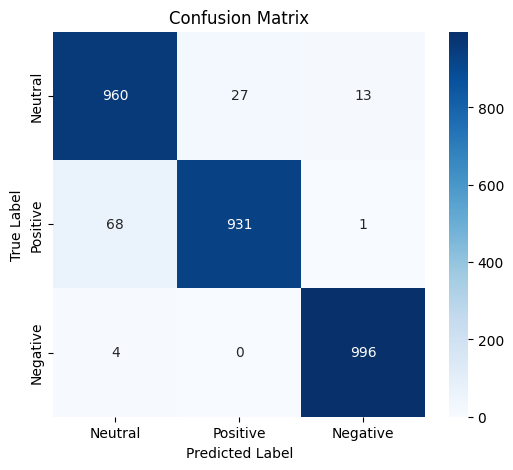

In [47]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Label mapping based on your dataset (adjust if needed)
labels = ["Neutral", "Positive", "Negative"]

# Create a heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


In [49]:
trainer.save_model("./first_model")  # saves model, tokenizer, config
tokenizer.save_pretrained("./first_model")


('./first_model/tokenizer_config.json',
 './first_model/special_tokens_map.json',
 './first_model/vocab.txt',
 './first_model/added_tokens.json',
 './first_model/tokenizer.json')

In [50]:
import tarfile

model_dir = "./first_model"
output_filename = "first_model.tar.gz"

with tarfile.open(output_filename, "w:gz") as tar:
    tar.add(model_dir, arcname="bert_sentiment_model")


In [ ]:
"""import shutil
shutil.make_archive("best_model", "zip", '/content/best_model')
"""